# GEFS (Claude)

> ⚠️ Claude made this notebook, and I didn't actually review it all 😁

## 🌪️ Herbie + GEFS: Unlocking Ensemble Forecasts from NOMADS

**Herbie now supports downloading GEFS (Global Ensemble Forecast System) data directly from NOMADS!**

This notebook demonstrates how to access and visualize ensemble forecast data, opening up powerful probabilistic weather analysis capabilities.

---

## What is GEFS?

The Global Ensemble Forecast System (GEFS) is NOAA's ensemble weather prediction system that runs **31 different forecast scenarios** (1 control + 30 perturbed members) to quantify forecast uncertainty. Instead of a single deterministic forecast, GEFS gives you a range of possible outcomes.

### Why GEFS matters:
- 📊 **Probabilistic forecasts**: Understand forecast confidence and uncertainty
- 🎯 **Risk assessment**: Identify extreme scenarios and their likelihood
- 🌍 **Global coverage**: 0.5° resolution out to 16 days
- 🔄 **Frequent updates**: Run 4 times daily (00, 06, 12, 18 UTC)

---

## 📦 Setup and Installation

In [12]:
from datetime import datetime, timedelta

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from herbie import Herbie

# Set up plotting style
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (16, 10)
plt.rcParams["font.size"] = 11

---

## 🎯 Example 1: Download a Single GEFS Member

Let's start by downloading data from one ensemble member.

In [4]:
# Download GEFS control member (member 0)
# Using recent model run
H = Herbie(
    date="2024-02-03 00:00",  # Model initialization time
    model="gefs",  # GEFS model
    product="atmos.25",  # 0.25° atmospheric product (also available: 0.5°, wave, chem)
    fxx=48,  # 48-hour forecast
    member=0,  # Control member (members 1-30 are perturbed)
)

# Check what variables are available
print("🔍 GEFS Inventory Sample:")
H.inventory(search="TMP:2 m|RH:2 m|UGRD:10 m|VGRD:10 m")

✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F48 ┊ GRIB2 @ aws ┊ IDX @ local
🔍 GEFS Inventory Sample:


,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,?,search_this
9,10,4017149,4769564.0,4017149-4769564,2024-02-03,2024-02-05,TMP,2 m above ground,48 hour fcst,ENS=low-res ctl,:TMP:2 m above ground:48 hour fcst:ENS=low-res...
11,12,5545203,6203602.0,5545203-6203602,2024-02-03,2024-02-05,RH,2 m above ground,48 hour fcst,ENS=low-res ctl,:RH:2 m above ground:48 hour fcst:ENS=low-res ...
14,15,7681067,8509336.0,7681067-8509336,2024-02-03,2024-02-05,UGRD,10 m above ground,48 hour fcst,ENS=low-res ctl,:UGRD:10 m above ground:48 hour fcst:ENS=low-r...
15,16,8509337,9319433.0,8509337-9319433,2024-02-03,2024-02-05,VGRD,10 m above ground,48 hour fcst,ENS=low-res ctl,:VGRD:10 m above ground:48 hour fcst:ENS=low-r...


In [10]:
# Download temperature and wind data
ds = H.xarray("TMP:2 m|UGRD:10 m|VGRD:10 m", remove_grib=True)

print("\n📊 Downloaded Dataset:")
ds = xr.merge(ds, compat="override")
ds

/home/blaylock/GITHUB/Herbie/.venv/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.

📊 Downloaded Dataset:


<xarray.Dataset> Size: 12MB
Dimensions:              (latitude: 721, longitude: 1440)
Coordinates:
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    number               int64 8B 0
    time                 datetime64[ns] 8B 2024-02-03
    step                 timedelta64[ns] 8B 2 days
    heightAboveGround    float64 8B 10.0
    valid_time           datetime64[ns] 8B 2024-02-05
    gribfile_projection  object 8B None
Data variables:
    u10                  (latitude, longitude) float32 4MB -4.088 ... -2.918
    v10                  (latitude, longitude) float32 4MB 2.724 ... -0.4465
    t2m                  (latitude, longitude) float32 4MB 263.1 263.1 ... 241.8
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   gefs
    product:                 atmos.25
    description:             Global Ensemble Forecast System (GEFS)
    remote_grib:             https://noaa-gefs-pds.s3.amazonaws.com/gefs.2024...
    local_grib:              /home/blaylock/data/gefs/20240203/subset_471ca12...
    search:                  TMP:2 m|UGRD:10 m|VGRD:10 m

---

## 🗺️ Example 2: Visualize the Control Forecast

Create a professional weather map from GEFS data.

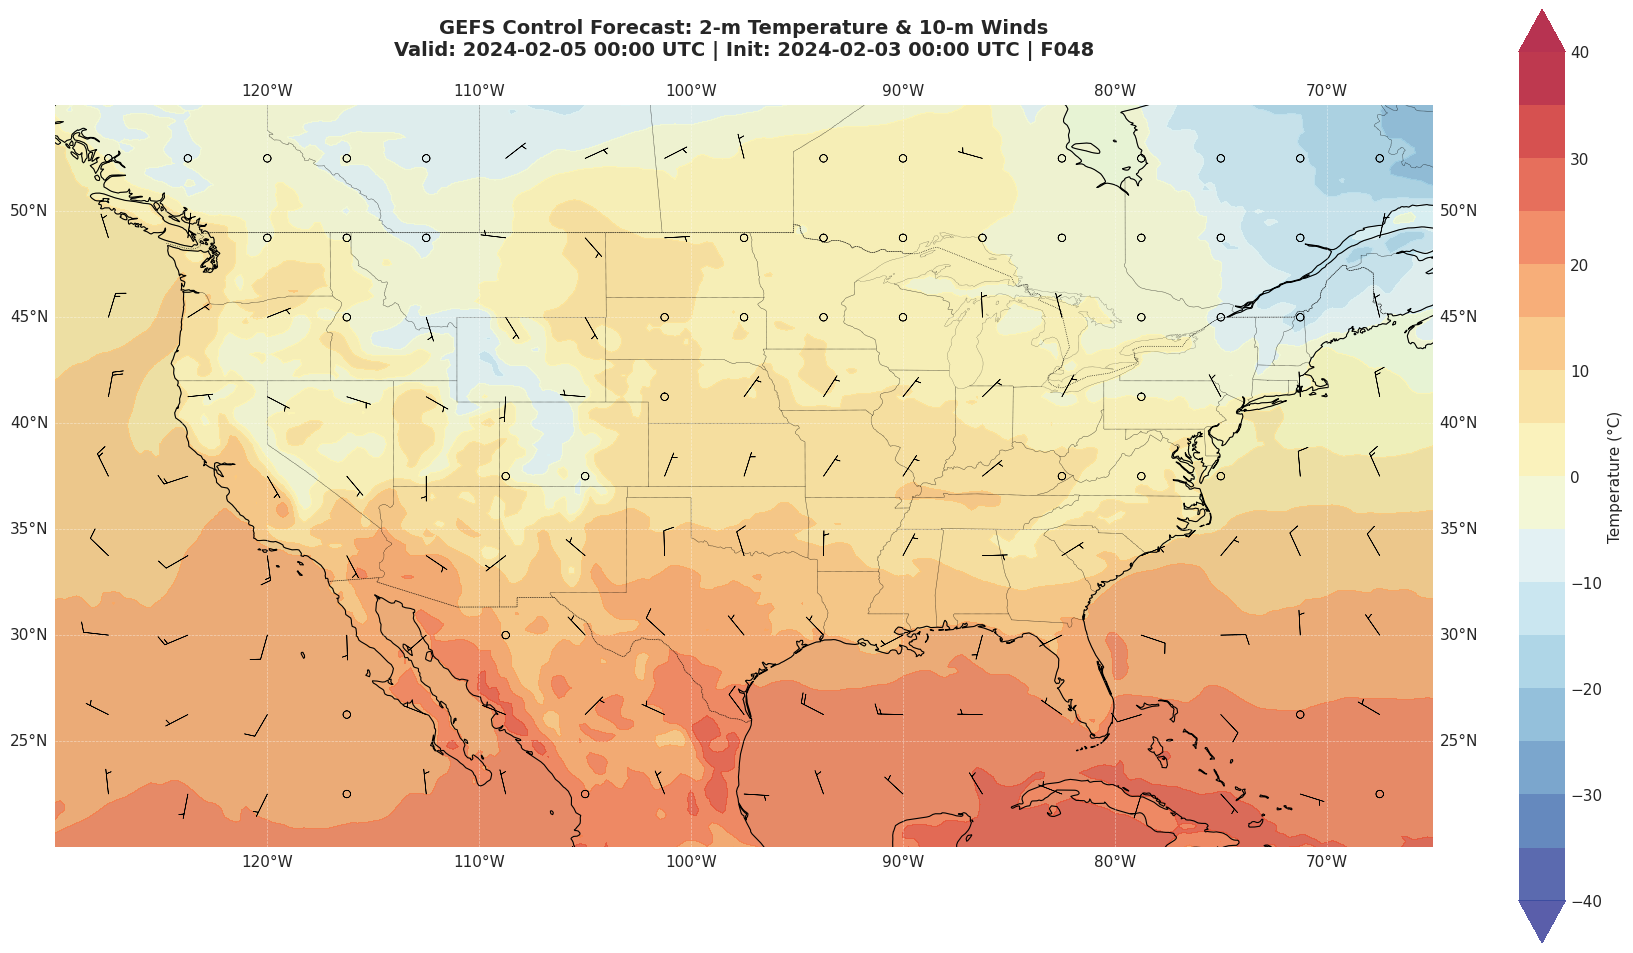


✅ Map shows GEFS control member forecast for F048


In [14]:
# Extract variables
temp = ds["t2m"] - 273.15  # Convert to Celsius
u_wind = ds["u10"]
v_wind = ds["v10"]
wind_speed = np.sqrt(u_wind**2 + v_wind**2) * 1.94384  # Convert to knots

# Create map
fig = plt.figure(figsize=(18, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, color="lightgray", zorder=1)
ax.add_feature(cfeature.OCEAN, color="lightblue", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":", zorder=2)
ax.add_feature(cfeature.STATES, linewidth=0.3, linestyle=":", zorder=2)

# Plot temperature
cf = ax.contourf(
    temp.longitude,
    temp.latitude,
    temp,
    levels=np.arange(-40, 45, 5),
    cmap="RdYlBu_r",
    transform=ccrs.PlateCarree(),
    extend="both",
    alpha=0.8,
    zorder=1,
)

# Add wind barbs (subsample for clarity)
skip = 15
ax.barbs(
    u_wind.longitude[::skip],
    u_wind.latitude[::skip],
    u_wind.values[::skip, ::skip],
    v_wind.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
    length=6,
    linewidth=0.5,
    zorder=3,
)

# Formatting
plt.colorbar(cf, ax=ax, label="Temperature (°C)", pad=0.05, shrink=0.8)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle="--")
ax.set_extent([-130, -65, 20, 55], crs=ccrs.PlateCarree())

valid_time = ds.valid_time.values
init_time = ds.time.values
plt.title(
    f"GEFS Control Forecast: 2-m Temperature & 10-m Winds\n"
    f"Valid: {pd.Timestamp(valid_time).strftime('%Y-%m-%d %H:%M UTC')} | "
    f"Init: {pd.Timestamp(init_time).strftime('%Y-%m-%d %H:%M UTC')} | "
    f"F{H.fxx:03d}",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.tight_layout()
plt.show()

print(f"\n✅ Map shows GEFS control member forecast for F{H.fxx:03d}")

---

## 🎲 Example 3: Download ALL Ensemble Members

The real power of GEFS is analyzing all 31 ensemble members together!

In [15]:
# Download multiple ensemble members
# Note: Downloading all 31 members takes time - we'll use a subset for demo
members_to_download = [0, 1, 5, 10, 15, 20, 25, 30]  # Mix of control + perturbed

print(f"📥 Downloading {len(members_to_download)} GEFS ensemble members...\n")

ensemble_data = []

for member in members_to_download:
    print(f"  → Member {member:02d}...", end=" ")

    H = Herbie(
        date="2024-02-03 00:00",
        model="gefs",
        product="atmos.25",
        fxx=120,  # 5-day forecast
        member=member,
    )

    ds = H.xarray("TMP:2 m", remove_grib=True)
    ensemble_data.append(ds["t2m"] - 273.15)  # Convert to Celsius

    print("✓")

# Stack into ensemble array
ensemble = xr.concat(ensemble_data, dim="member")
ensemble = ensemble.assign_coords(member=members_to_download)

print(f"\n✅ Downloaded ensemble shape: {ensemble.shape}")
print(
    f"   (members, latitude, longitude) = ({len(members_to_download)}, {ensemble.shape[1]}, {ensemble.shape[2]})"
)

📥 Downloading 8 GEFS ensemble members...

  → Member 00... ✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws
✓
  → Member 01... ✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws
✓
  → Member 05... ✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws
✓
  → Member 10... ✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws
✓
  → Member 15... ✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws
✓
  → Member 20... ✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws
✓
  → Member 25... ✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws
✓
  → Member 30... ✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws
✓

✅ Downloaded ensemble shape: (8, 721, 1440)
 

---

## 📊 Example 4: Ensemble Statistics and Uncertainty

Calculate probabilistic metrics from the ensemble.

In [16]:
# Calculate ensemble statistics
ensemble_mean = ensemble.mean(dim="member")
ensemble_std = ensemble.std(dim="member")
ensemble_min = ensemble.min(dim="member")
ensemble_max = ensemble.max(dim="member")

# Calculate probability of freezing (temperature < 0°C)
prob_freezing = (ensemble < 0).sum(dim="member") / len(members_to_download) * 100

print("📈 Ensemble Statistics Calculated:")
print(f"   • Mean temperature: {float(ensemble_mean.mean()):.1f}°C")
print(f"   • Std deviation: {float(ensemble_std.mean()):.1f}°C")
print(
    f"   • Range: {float(ensemble_min.min()):.1f}°C to {float(ensemble_max.max()):.1f}°C"
)
print(f"   • Max uncertainty: {float(ensemble_std.max()):.1f}°C")

📈 Ensemble Statistics Calculated:
   • Mean temperature: 4.3°C
   • Std deviation: 1.2°C
   • Range: -46.6°C to 40.2°C
   • Max uncertainty: 8.6°C


---

## 🎨 Example 5: Visualize Ensemble Spread

Create a 4-panel plot showing ensemble mean, spread, and uncertainty.

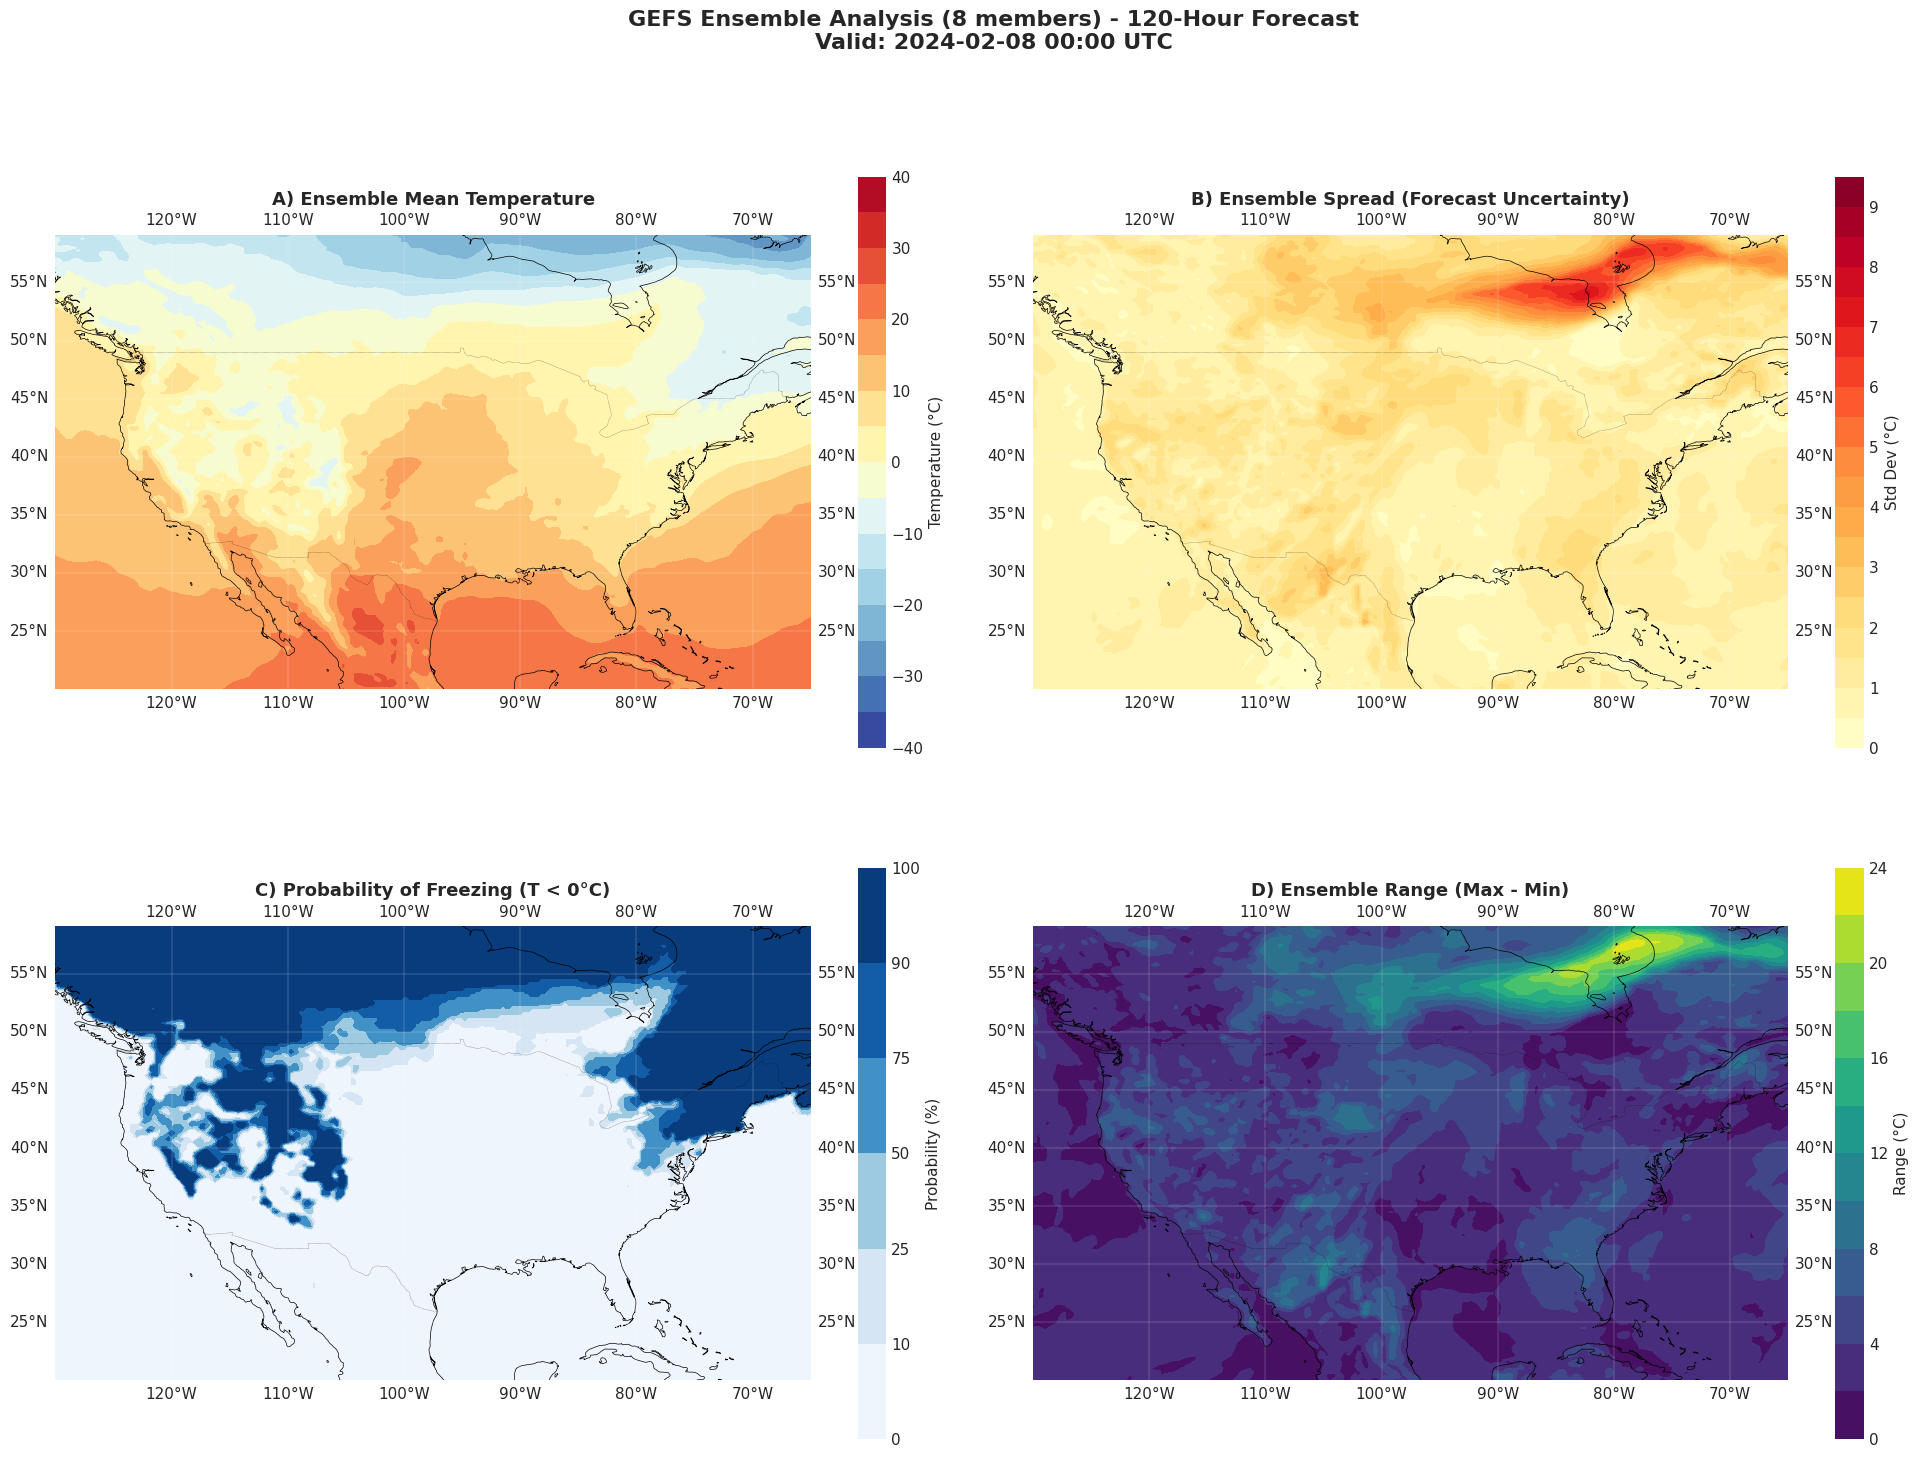


✅ 4-panel ensemble visualization complete!
   Higher spread (panel B) = lower forecast confidence
   Larger range (panel D) = more member disagreement


In [17]:
fig = plt.figure(figsize=(20, 16))

# Define common extent
extent = [-130, -65, 20, 55]

# Panel 1: Ensemble Mean
ax1 = plt.subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, color="lightgray")
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
cf1 = ax1.contourf(
    ensemble_mean.longitude,
    ensemble_mean.latitude,
    ensemble_mean,
    levels=np.arange(-40, 45, 5),
    cmap="RdYlBu_r",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(cf1, ax=ax1, label="Temperature (°C)", shrink=0.7)
ax1.set_extent(extent)
ax1.set_title("A) Ensemble Mean Temperature", fontsize=13, fontweight="bold")
ax1.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Panel 2: Ensemble Spread (Std Dev)
ax2 = plt.subplot(2, 2, 2, projection=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, color="lightgray")
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
cf2 = ax2.contourf(
    ensemble_std.longitude,
    ensemble_std.latitude,
    ensemble_std,
    levels=np.arange(0, 10, 0.5),
    cmap="YlOrRd",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(cf2, ax=ax2, label="Std Dev (°C)", shrink=0.7)
ax2.set_extent(extent)
ax2.set_title(
    "B) Ensemble Spread (Forecast Uncertainty)", fontsize=13, fontweight="bold"
)
ax2.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Panel 3: Probability of Freezing
ax3 = plt.subplot(2, 2, 3, projection=ccrs.PlateCarree())
ax3.add_feature(cfeature.LAND, color="lightgray")
ax3.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax3.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
cf3 = ax3.contourf(
    prob_freezing.longitude,
    prob_freezing.latitude,
    prob_freezing,
    levels=[0, 10, 25, 50, 75, 90, 100],
    cmap="Blues",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(cf3, ax=ax3, label="Probability (%)", shrink=0.7)
ax3.set_extent(extent)
ax3.set_title("C) Probability of Freezing (T < 0°C)", fontsize=13, fontweight="bold")
ax3.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Panel 4: Ensemble Range
ax4 = plt.subplot(2, 2, 4, projection=ccrs.PlateCarree())
ax4.add_feature(cfeature.LAND, color="lightgray")
ax4.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax4.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
ensemble_range = ensemble_max - ensemble_min
cf4 = ax4.contourf(
    ensemble_range.longitude,
    ensemble_range.latitude,
    ensemble_range,
    levels=np.arange(0, 25, 2),
    cmap="viridis",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(cf4, ax=ax4, label="Range (°C)", shrink=0.7)
ax4.set_extent(extent)
ax4.set_title("D) Ensemble Range (Max - Min)", fontsize=13, fontweight="bold")
ax4.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

plt.suptitle(
    f"GEFS Ensemble Analysis ({len(members_to_download)} members) - 120-Hour Forecast\n"
    f"Valid: {pd.Timestamp(ensemble.valid_time.values).strftime('%Y-%m-%d %H:%M UTC')}",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()
plt.show()

print("\n✅ 4-panel ensemble visualization complete!")
print("   Higher spread (panel B) = lower forecast confidence")
print("   Larger range (panel D) = more member disagreement")

---

## 🌪️ Example 6: Spaghetti Plot

Create a classic "spaghetti plot" showing individual ensemble member forecasts.

In [19]:
# Select a specific location for time series
# Example: New York City
lat_nyc, lon_nyc = 40.7, -74.0

# Download time series for multiple forecast hours
forecast_hours = range(0, 24, 6)  # 0 to 168 hours, every 6 hours

print(f"📥 Downloading {len(forecast_hours)} forecast hours for spaghetti plot...\n")

time_series_data = {member: [] for member in members_to_download}

for fxx in forecast_hours:
    print(f"  → F{fxx:03d}...", end=" ")

    for member in members_to_download:
        H = Herbie(
            date="2024-02-03 00:00",
            model="gefs",
            product="atmos.25",
            fxx=fxx,
            member=member,
        )

        ds = H.xarray("TMP:2 m", remove_grib=True)

        # Extract nearest point to NYC
        temp_point = (
            ds["t2m"].sel(latitude=lat_nyc, longitude=lon_nyc, method="nearest")
            - 273.15
        )

        time_series_data[member].append(float(temp_point.values))

    print("✓")

print("\n✅ Time series data downloaded!")

📥 Downloading 4 forecast hours for spaghetti plot...

  → F000... ✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
✓
  → F006... ✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Feb-03 00

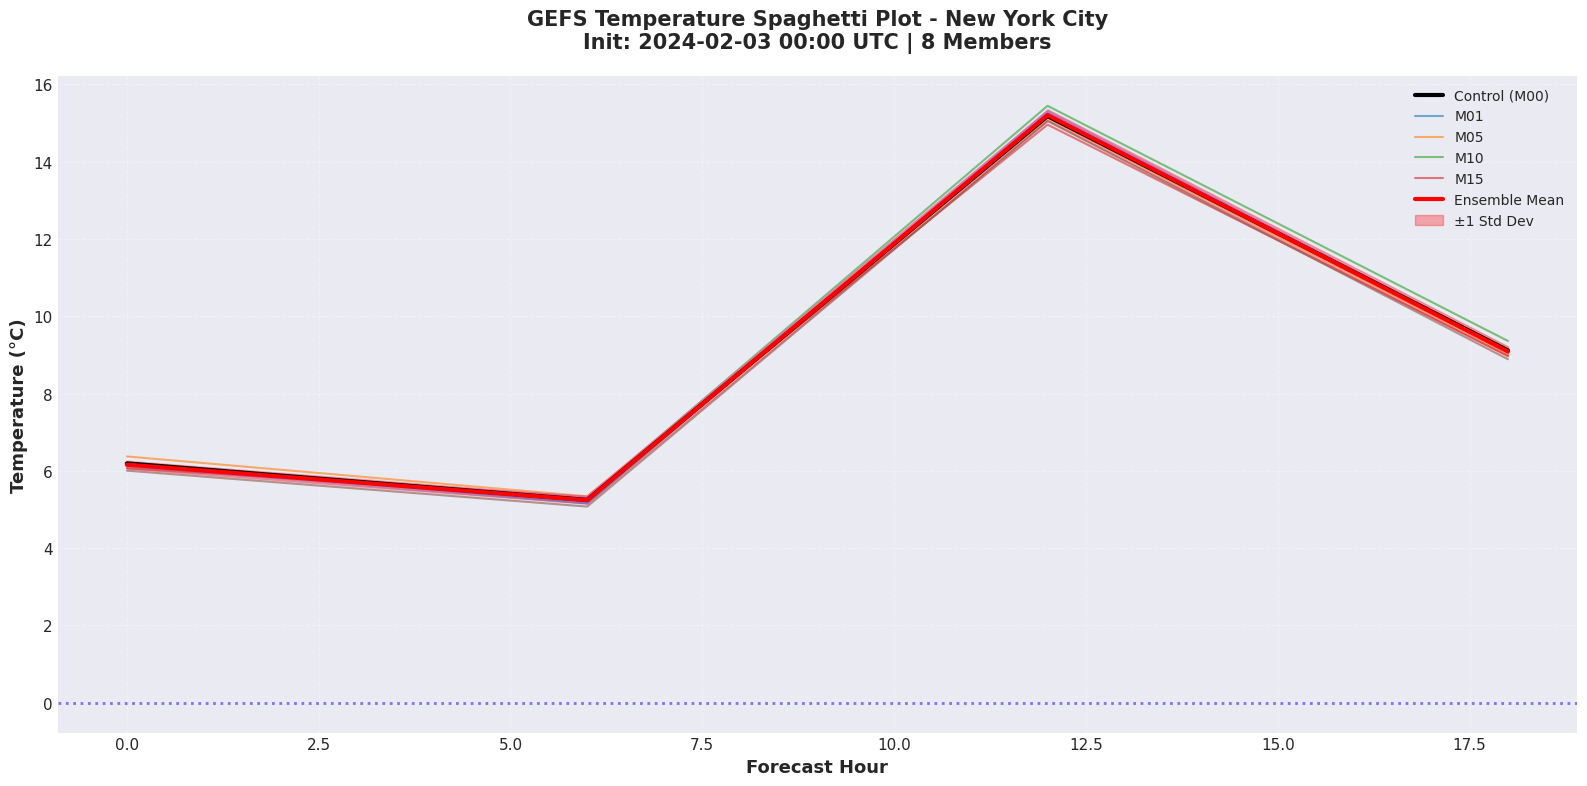


✅ Spaghetti plot complete!
   Each line represents a different ensemble member
   Wider spread = higher forecast uncertainty


In [20]:
# Create spaghetti plot
fig, ax = plt.subplots(figsize=(16, 8))

# Plot each ensemble member
for i, member in enumerate(members_to_download):
    if member == 0:
        # Control member - make it stand out
        ax.plot(
            forecast_hours,
            time_series_data[member],
            "k-",
            linewidth=3,
            label="Control (M00)",
            zorder=10,
        )
    else:
        # Perturbed members
        ax.plot(
            forecast_hours,
            time_series_data[member],
            alpha=0.6,
            linewidth=1.5,
            label=f"M{member:02d}" if i < 5 else None,  # Limit legend entries
        )

# Calculate and plot ensemble mean
ensemble_mean_ts = np.mean([time_series_data[m] for m in members_to_download], axis=0)
ax.plot(
    forecast_hours,
    ensemble_mean_ts,
    "r-",
    linewidth=3,
    label="Ensemble Mean",
    zorder=11,
)

# Calculate and plot uncertainty envelope
ensemble_std_ts = np.std([time_series_data[m] for m in members_to_download], axis=0)
ax.fill_between(
    forecast_hours,
    ensemble_mean_ts - ensemble_std_ts,
    ensemble_mean_ts + ensemble_std_ts,
    alpha=0.3,
    color="red",
    label="±1 Std Dev",
)

# Formatting
ax.set_xlabel("Forecast Hour", fontsize=13, fontweight="bold")
ax.set_ylabel("Temperature (°C)", fontsize=13, fontweight="bold")
ax.set_title(
    f"GEFS Temperature Spaghetti Plot - New York City\n"
    f"Init: 2024-02-03 00:00 UTC | {len(members_to_download)} Members",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="best", fontsize=10)
ax.axhline(y=0, color="blue", linestyle=":", linewidth=2, alpha=0.5, label="Freezing")

plt.tight_layout()
plt.show()

print("\n✅ Spaghetti plot complete!")
print("   Each line represents a different ensemble member")
print("   Wider spread = higher forecast uncertainty")

---

## 🎯 Example 7: Extreme Scenario Analysis

Identify and visualize the warmest and coldest ensemble members.

🔥 Warmest ensemble member: M10 (4.4°C avg)
❄️  Coldest ensemble member: M05 (4.1°C avg)
📊 Temperature difference: 0.2°C


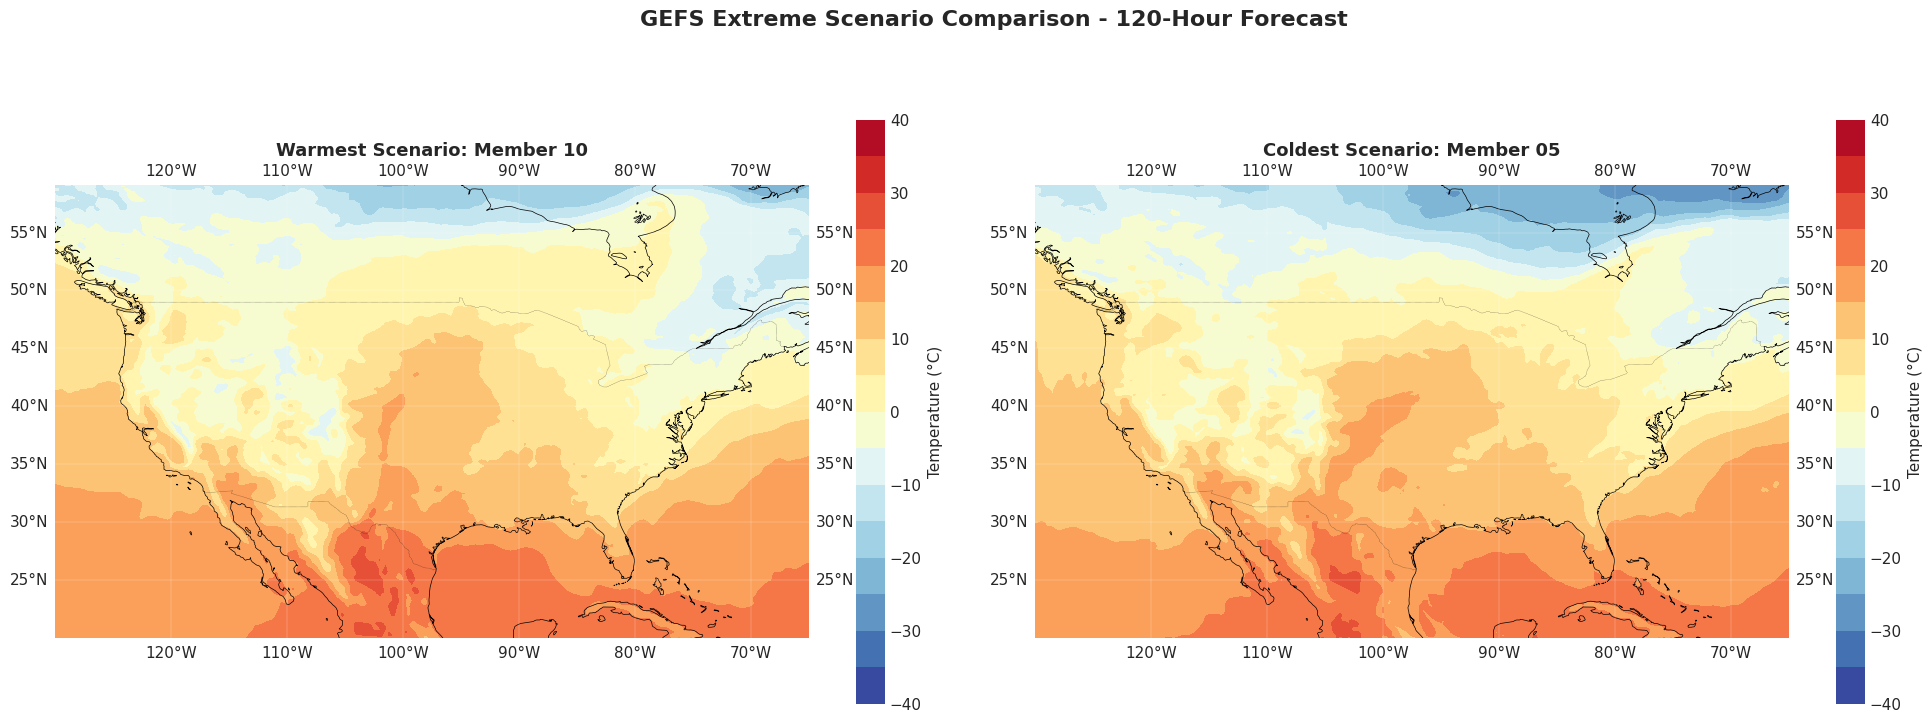

In [21]:
# Find warmest and coldest members (by spatial average)
spatial_means = {}
for member in members_to_download:
    member_data = ensemble.sel(member=member)
    spatial_means[member] = float(member_data.mean())

warmest_member = max(spatial_means, key=spatial_means.get)
coldest_member = min(spatial_means, key=spatial_means.get)

print(
    f"🔥 Warmest ensemble member: M{warmest_member:02d} ({spatial_means[warmest_member]:.1f}°C avg)"
)
print(
    f"❄️  Coldest ensemble member: M{coldest_member:02d} ({spatial_means[coldest_member]:.1f}°C avg)"
)
print(
    f"📊 Temperature difference: {spatial_means[warmest_member] - spatial_means[coldest_member]:.1f}°C"
)

# Visualize comparison
fig = plt.figure(figsize=(20, 8))

# Warmest member
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, color="lightgray")
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
cf1 = ax1.contourf(
    ensemble.longitude,
    ensemble.latitude,
    ensemble.sel(member=warmest_member),
    levels=np.arange(-40, 45, 5),
    cmap="RdYlBu_r",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(cf1, ax=ax1, label="Temperature (°C)", shrink=0.8)
ax1.set_extent(extent)
ax1.set_title(
    f"Warmest Scenario: Member {warmest_member:02d}", fontsize=13, fontweight="bold"
)
ax1.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Coldest member
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, color="lightgray")
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
cf2 = ax2.contourf(
    ensemble.longitude,
    ensemble.latitude,
    ensemble.sel(member=coldest_member),
    levels=np.arange(-40, 45, 5),
    cmap="RdYlBu_r",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(cf2, ax=ax2, label="Temperature (°C)", shrink=0.8)
ax2.set_extent(extent)
ax2.set_title(
    f"Coldest Scenario: Member {coldest_member:02d}", fontsize=13, fontweight="bold"
)
ax2.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

plt.suptitle(
    "GEFS Extreme Scenario Comparison - 120-Hour Forecast",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()
plt.show()

---

## 🚀 Advanced Use Cases

Here are some powerful applications you can build with GEFS data:

### 1. **Severe Weather Risk Assessment**
```python
# Calculate probability of severe weather criteria
# Example: Probability of wind gusts > 40 knots

# Download all 31 members with wind data
# Calculate exceedance probability at each grid point
# Create risk maps for decision-making
```

### 2. **Agriculture Frost Forecasts**
```python
# Determine frost probability for crop protection
# Calculate probability of T < -2°C at 2m
# Analyze timing and duration of freezing conditions
# Generate alerts based on ensemble consensus
```

### 3. **Renewable Energy Planning**
```python
# Wind farm output forecasting
# Download wind speed ensembles at turbine height
# Convert to power output probabilities
# Optimize grid scheduling with uncertainty bounds
```

### 4. **Aviation Weather Decision Support**
```python
# Icing probability forecasts
# Turbulence likelihood assessment
# Visibility and ceiling probabilities
# Route optimization with weather uncertainty
```

### 5. **Hydrological Forecasting**
```python
# Precipitation ensemble analysis
# Flood risk probability assessment
# Snowmelt timing uncertainty
# Drought monitoring and prediction
```

---

## 📚 Available GEFS Products

Herbie supports multiple GEFS product streams:

| Product | Resolution | Domain | Variables |
|---------|-----------|--------|----------|
| `atmos.25` | 0.25° | Global | Full atmospheric suite |
| `atmos.50` | 0.50° | Global | Full atmospheric suite |
| `wave.global` | 0.50° | Global | Wave height, period, direction |
| `chem` | 1.00° | Global | Aerosols, trace gases |

### Key Variables Available:
- **Temperature**: 2m temp, dewpoint, surface temp
- **Winds**: 10m winds, winds at pressure levels
- **Precipitation**: Total, convective, snow
- **Moisture**: RH, PWAT, cloud cover
- **Pressure**: MSLP, heights, vertical velocity
- **Radiation**: Incoming/outgoing SW/LW
- **And many more!**

---

## ⚡ Performance Tips

**1. Download efficiently:**
```python
# Use specific variable search to reduce file size
H.xarray('TMP:2 m|RH:2 m')  # Only what you need

# Use subset_points for specific locations
H.xarray('TMP:2 m', subset_points=[(lat, lon)])
```

**2. Parallel downloads:**
```python
from concurrent.futures import ThreadPoolExecutor

def download_member(member):
    H = Herbie(date='2024-02-03', model='gefs', 
               product='atmos.25', fxx=48, member=member)
    return H.xarray('TMP:2 m')

with ThreadPoolExecutor(max_workers=5) as executor:
    results = list(executor.map(download_member, range(31)))
```

**3. Cache downloaded files:**
```python
# Herbie automatically caches GRIB files
# Reusing the same Herbie object is fast!
```

---

## 🎓 Learning Resources

**GEFS Documentation:**
- [GEFS Overview (NOAA)](https://www.ncei.noaa.gov/products/weather-climate-models/global-ensemble-forecast)
- [GEFS Technical Details](https://www.emc.ncep.noaa.gov/emc/pages/numerical_forecast_systems/gefs.php)

**Herbie Documentation:**
- [Herbie GitHub](https://github.com/blaylockbk/Herbie)
- [Herbie Documentation](https://herbie.readthedocs.io/)

**Ensemble Forecasting Concepts:**
- [ECMWF Ensemble Forecasting](https://www.ecmwf.int/en/research/modelling-and-prediction/ensemble-prediction-system)
- [WMO Guidelines on Ensemble Prediction Systems](https://library.wmo.int/index.php?lvl=notice_display&id=20200)

**Python Weather Tools:**
- [MetPy](https://unidata.github.io/MetPy/latest/index.html)
- [xarray](https://docs.xarray.dev/)
- [Cartopy](https://scitools.org.uk/cartopy/)

---

## 🎉 Summary

**What we've demonstrated:**

✅ Downloading single GEFS ensemble members  
✅ Downloading and analyzing multiple members  
✅ Calculating ensemble statistics (mean, spread, probabilities)  
✅ Creating professional weather visualizations  
✅ Building spaghetti plots for time series analysis  
✅ Identifying extreme scenarios  

**Why this matters:**

GEFS ensemble forecasts provide **probabilistic information** that single deterministic forecasts cannot. With Herbie's NOMADS support, you can now easily access this powerful data for:

- 🎯 **Better decision-making** with quantified uncertainty
- 📊 **Risk assessment** across multiple scenarios  
- 🌪️ **Extreme event analysis** and preparedness  
- 🔬 **Research applications** in weather and climate  

---

### 🚀 Get Started Today!

```bash
pip install herbie-data
```

```python
from herbie import Herbie

# Your first GEFS download:
H = Herbie(date='2024-02-03', model='gefs', 
           product='atmos.25', fxx=48, member=0)
ds = H.xarray('TMP:2 m')
```

**Happy forecasting! 🌤️**